In [1]:
import json
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = pathlib.Path("..")
RESULTS_DIR = ROOT / "results" / "linguistic_mistral" / "message"
DIMS = ["conviction", "anchoring", "dialogic"]
MAX_REP = 4

CAT = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a"]
SURFACE = "#fcfcfb"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "text.color": TEXT_PRIMARY,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 10,
})

In [2]:
rows = []
for f in RESULTS_DIR.glob("**/*.json"):
    rows.extend(json.loads(f.read_text()))
df = pd.DataFrame(rows)
df = df[df["rep_idx"] <= MAX_REP].reset_index(drop=True)
print(f"{len(df):,} rows | reps 0–{MAX_REP} | topologies: {df['topology'].value_counts().to_dict()} | W: {sorted(df['W'].unique())}")
df.head()

30,760 rows | reps 0–4 | topologies: {'star': 17256, 'fc': 13504} | W: [np.int64(1), np.int64(2), np.int64(5)]


,dataset,topology,W,qid,rep_idx,round,agent_idx,agent_id,conviction,anchoring,dialogic
0,gpqa,star,1,84,0,1,0,0,4,3,2
1,gpqa,star,1,84,0,1,1,1,4,4,4
2,gpqa,star,1,84,0,1,2,2,4,3,4
3,gpqa,star,1,84,0,1,3,3,5,4,5
4,gpqa,star,1,84,1,1,0,0,3,3,2


In [3]:
print("=== Summary statistics ===")
print(df[DIMS].describe().round(2))
print("\n=== Value counts ===")
for dim in DIMS:
    vc = df[dim].value_counts().sort_index()
    pct = (vc / vc.sum() * 100).round(1)
    print(f"\n{dim}:")
    print(pd.DataFrame({"n": vc, "%": pct}))

=== Summary statistics ===
       conviction  anchoring  dialogic
count    30760.00   30760.00  30760.00
mean         3.42       2.39      2.77
std          0.53       1.12      1.34
min          2.00       1.00      1.00
25%          3.00       1.00      2.00
50%          3.00       3.00      3.00
75%          4.00       3.00      4.00
max          5.00       5.00      5.00

=== Value counts ===

conviction:
                n     %
conviction             
2              59   0.2
3           18104  58.9
4           12068  39.2
5             529   1.7

anchoring:
               n     %
anchoring             
1          10263  33.4
2           3557  11.6
3          11581  37.6
4           5334  17.3
5             25   0.1

dialogic:
              n     %
dialogic             
1          7630  24.8
2          7577  24.6
3          1632   5.3
4         12198  39.7
5          1723   5.6


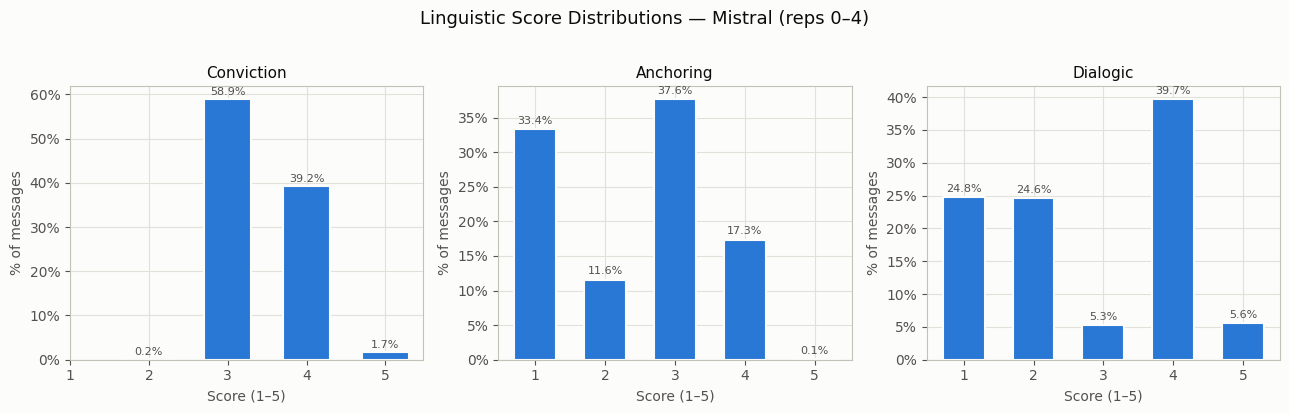

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Linguistic Score Distributions — Mistral (reps 0–4)", fontsize=13, y=1.02, color=TEXT_PRIMARY)

for ax, dim in zip(axes, DIMS):
    counts = df[dim].value_counts().sort_index()
    pct = counts / counts.sum() * 100
    bars = ax.bar(pct.index, pct.values, color=CAT[0], edgecolor=SURFACE, linewidth=1.5, width=0.6)
    ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRIMARY)
    ax.set_xlabel("Score (1–5)", color=TEXT_SECONDARY)
    ax.set_ylabel("% of messages", color=TEXT_SECONDARY)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    for bar, v in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=8, color=TEXT_SECONDARY)

plt.tight_layout()
plt.show()

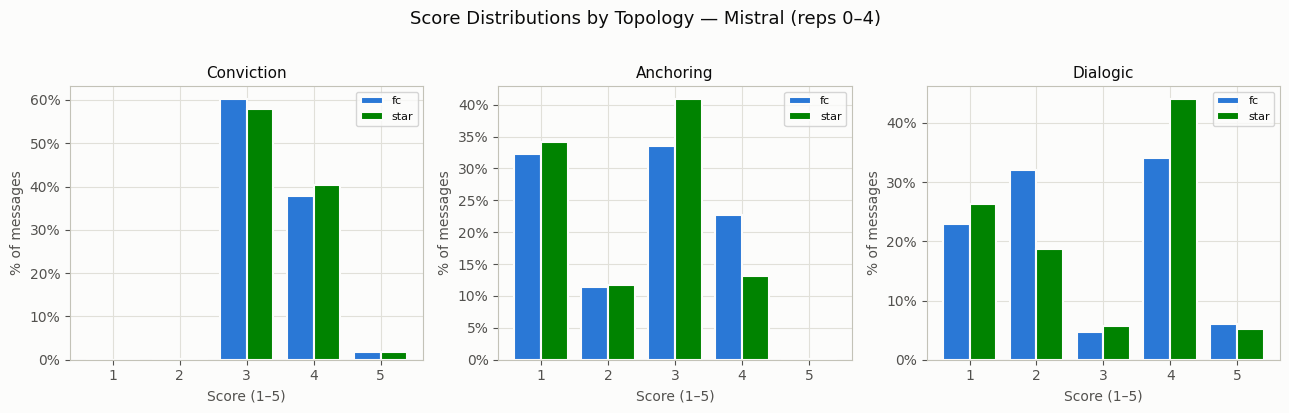

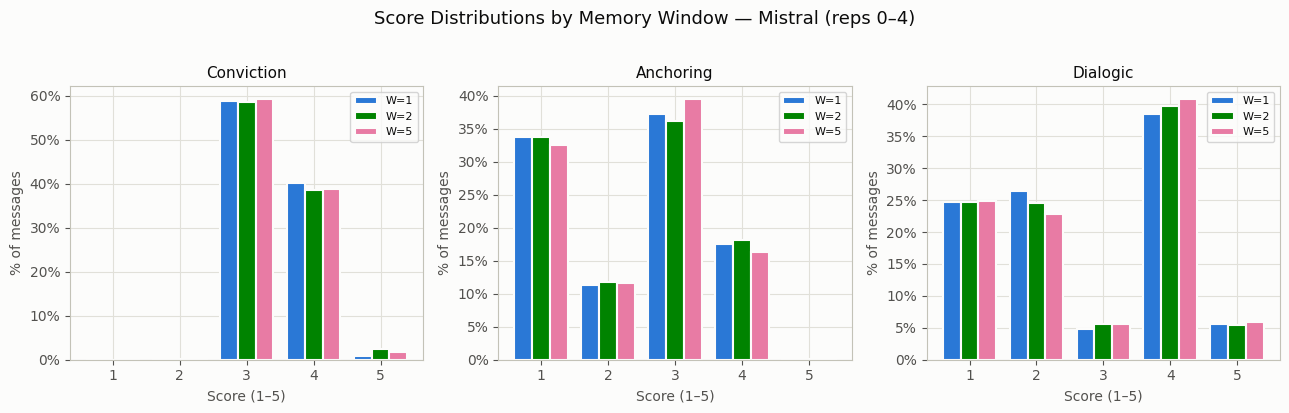

In [5]:
def plot_by_group(df, group_col, label_fn, title_suffix):
    groups = sorted(df[group_col].unique())
    colors = {g: CAT[i] for i, g in enumerate(groups)}
    width = 0.8 / max(len(groups), 1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(f"Score Distributions by {title_suffix} — Mistral (reps 0–4)", fontsize=13, y=1.02, color=TEXT_PRIMARY)
    for ax, dim in zip(axes, DIMS):
        for i, g in enumerate(groups):
            sub = df[df[group_col] == g]
            counts = sub[dim].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
            pct = counts / counts.sum() * 100
            offset = (i - len(groups) / 2 + 0.5) * width
            ax.bar([x + offset for x in pct.index], pct.values,
                   width=width, label=label_fn(g), color=colors[g], edgecolor=SURFACE, linewidth=1.5)
        ax.set_title(dim.capitalize(), fontsize=11, color=TEXT_PRIMARY)
        ax.set_xlabel("Score (1–5)", color=TEXT_SECONDARY)
        ax.set_ylabel("% of messages", color=TEXT_SECONDARY)
        ax.set_xticks([1, 2, 3, 4, 5])
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_by_group(df, "topology", lambda g: g,        "Topology")
plot_by_group(df, "W",        lambda g: f"W={g}",  "Memory Window")